In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\soura\Downloads\archive (1)\Teen_Mental_Health_Dataset.csv")

df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Shape of dataset: (2500, 12)

Columns:
 Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'depression_risk'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interacti

In [5]:
print("\nMissing values:\n")
print(df.isnull().sum())


Missing values:

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
depression_risk             0
dtype: int64


In [6]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


In [7]:
# Drop missing values (simple cleaning)
df = df.dropna()

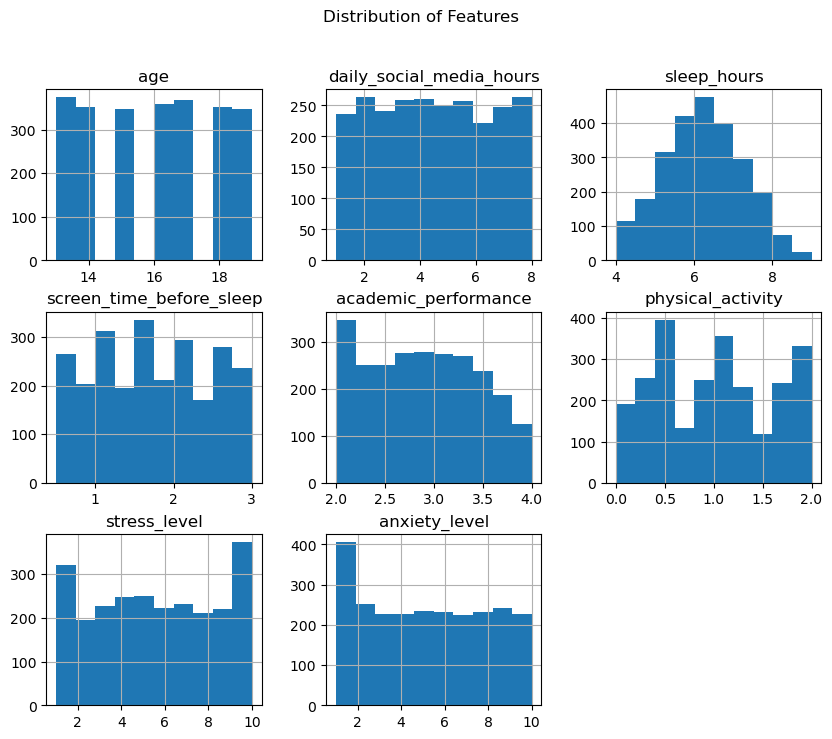

In [8]:
df.hist(figsize=(10,8))
plt.suptitle("Distribution of Features")
plt.show()

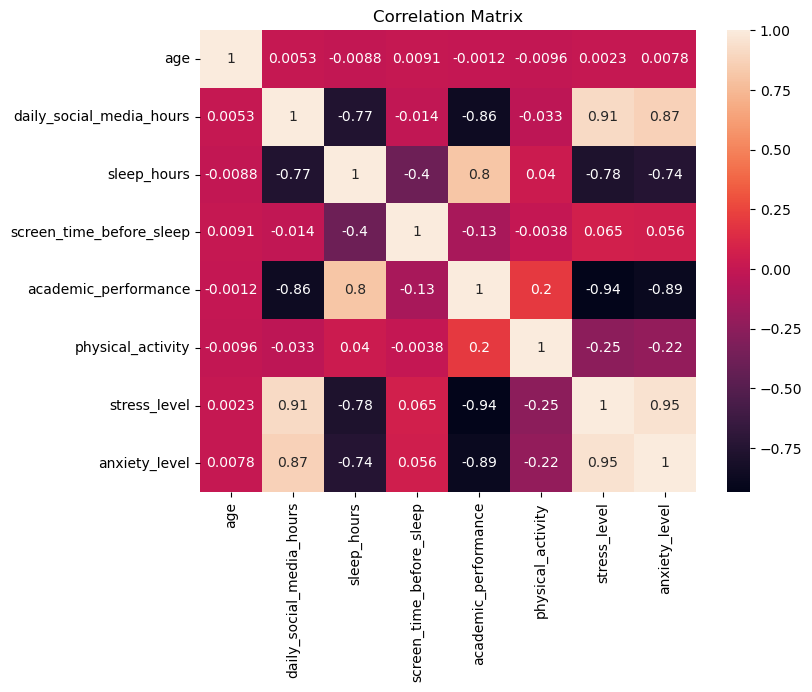

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

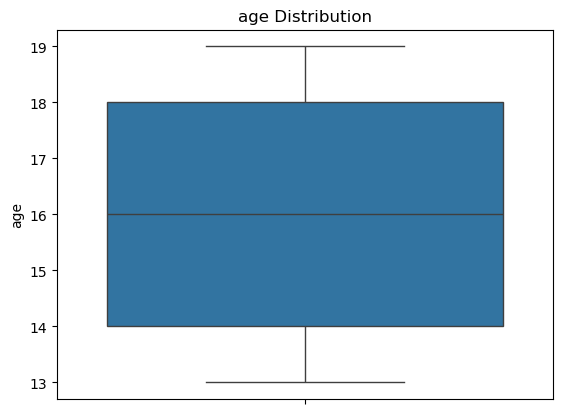

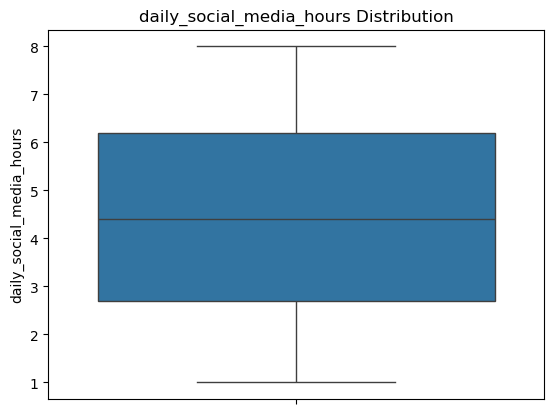

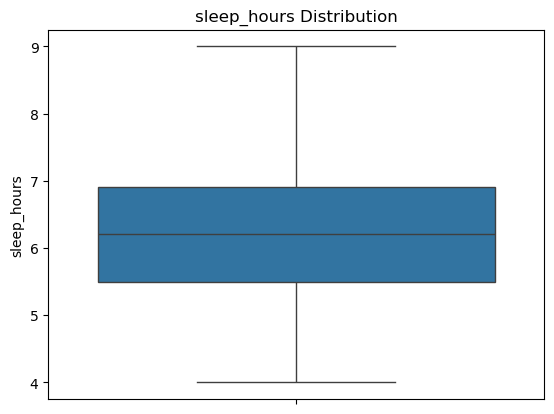

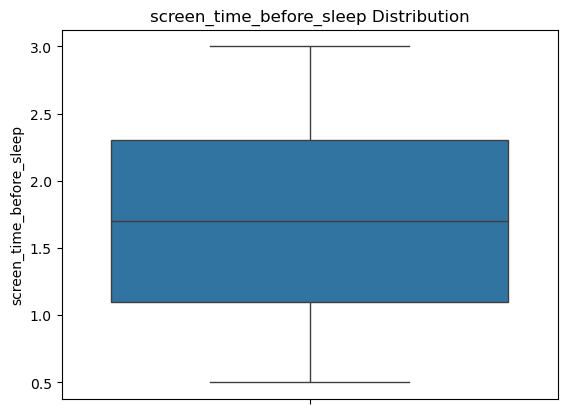

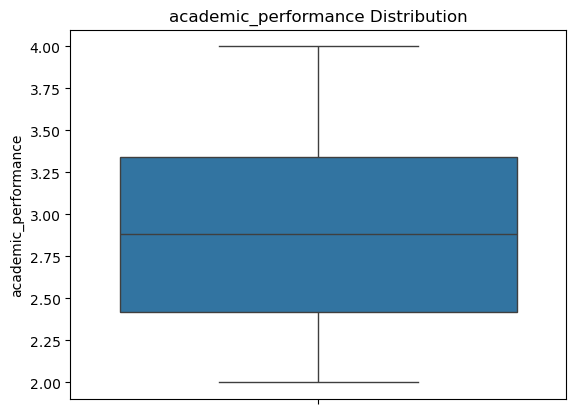

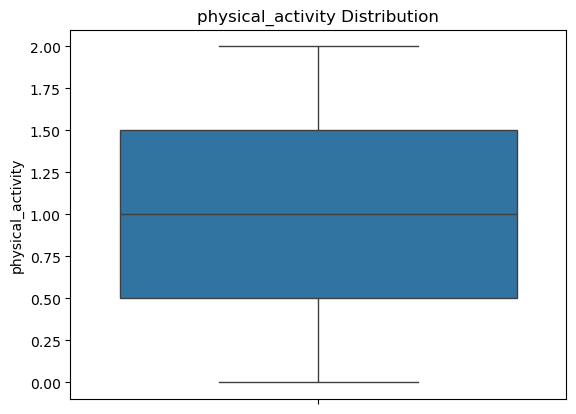

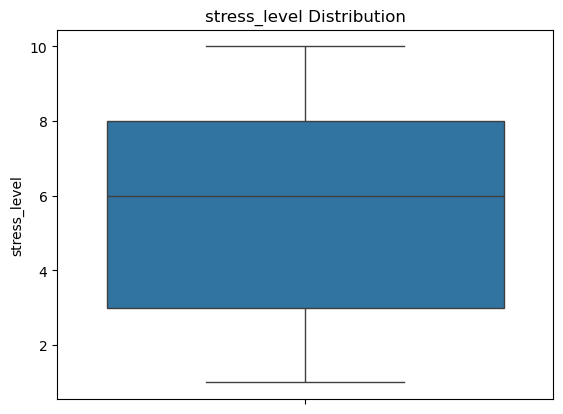

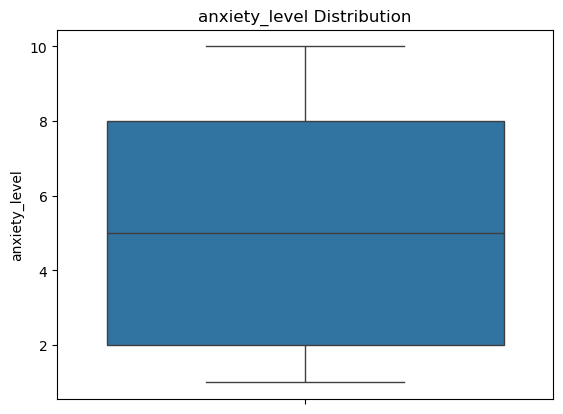

In [10]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"{col} Distribution")
    plt.show()

In [11]:
print("Summary Insights:\n")

for col in df.select_dtypes(include='number').columns:
    print(f"{col} average:", df[col].mean())

Summary Insights:

age average: 15.978
daily_social_media_hours average: 4.4580400000000004
sleep_hours average: 6.19244
screen_time_before_sleep average: 1.7147599999999998
academic_performance average: 2.890944
physical_activity average: 0.9917600000000001
stress_level average: 5.5964
anxiety_level average: 5.1648


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convert categorical columns to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Select features and target (last column assumed target)
X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.886
